In [ ]:
!pip install torchinfo

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

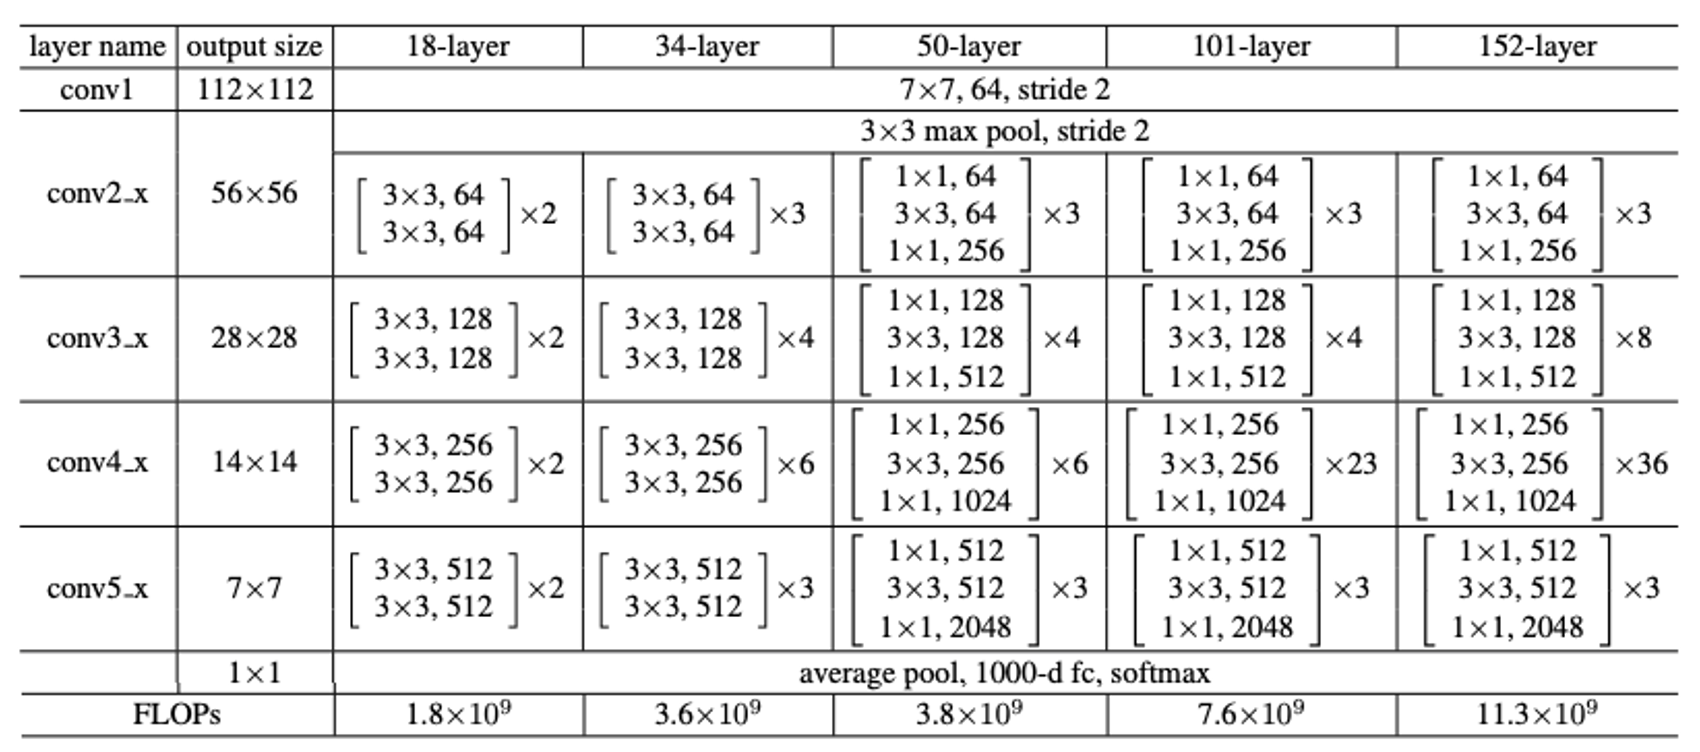

In [ ]:
# BasicBlock: ResNet-18, ResNet-34에서 사용하는 기본 블록(벽돌)입니다.
# ResNet의 핵심 아이디어인 '잔차 학습(Residual Learning)'을 구현한 부분입니다.
# 목표: 네트워크가 깊어져도 학습이 잘 되도록 '성능 저하 문제(Degradation Problem)'를 해결하는 것.
# 비유: 복잡한 골목길(Conv 레이어) 옆에 뻥 뚫린 고속도로(Shortcut)를 만들어, 최소한 현상 유지는 쉽게 하도록 보장해주는 구조.
class BasicBlock(nn.Module):
    # 'expansion'은 블록 내에서 마지막 출력 채널의 확장 비율을 의미합니다.
    # BasicBlock에서는 입력 채널과 출력 채널의 수가 변하지 않으므로, 확장 비율은 1입니다.
    # (참고: ResNet-50 이상의 Bottleneck 블록에서는 이 값이 4로, 채널을 확장시켰다가 다시 줄이는 구조를 가집니다.)
    expansion = 1

    # 객체가 생성될 때 실행되는 '설계도' 부분입니다. 블록에 필요한 레이어들을 미리 정의합니다.
    # - in_channels: 이 블록으로 들어오는 입력 데이터의 채널(두께) 수
    # - out_channels: 이 블록의 주된 경로(메인 연산)를 거친 후의 출력 채널 수
    # - stride: 컨볼루션 연산 시 필터가 몇 칸씩 이동할지 결정하는 '보폭'. 1이면 크기 유지, 2이면 가로/세로가 절반으로 줄어듦.
    # - downsample: '고속도로' 경로의 데이터와 '골목길' 경로의 데이터의 규격을 맞춰주기 위한 특별 모듈.
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()

        # --- '골목길' 경로(주된 특징 추출 경로) 정의 ---

        # 첫 번째 3x3 컨볼루션 레이어입니다.
        # stride 값에 따라 입력 이미지의 크기가 여기서 처음으로 조절될 수 있습니다.
        # padding=1: kernel_size=3일 때 입력과 출력의 가로/세로 크기를 동일하게 유지시켜주는 설정입니다. (stride=1일 경우)
        # bias=False: 바로 뒤에 BatchNorm2d 레이어가 오기 때문에 bias 항이 필요 없습니다. BatchNorm의 beta 파라미터가 bias 역할을 대신하여 중복을 제거합니다.
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)

        # 배치 정규화(Batch Normalization): 데이터의 분포를 안정화시켜 학습을 더 빠르고 안정적으로 만듭니다. 일종의 '학습 촉진제'.
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 활성화 함수(ReLU): 음수 값은 0으로 만들고, 양수 값은 그대로 두어 비선형성을 추가합니다. 이게 없으면 깊게 쌓는 의미가 없습니다.
        self.relu = nn.ReLU(inplace=True)

        # 두 번째 3x3 컨볼루션 레이어입니다.
        # 여기서는 항상 stride=1을 사용하여 이미지 크기를 변경하지 않습니다. 크기 조절은 conv1에서만 담당합니다.
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)

        # 두 번째 컨볼루션 연산 후에도 배치 정규화를 적용합니다.
        self.bn2 = nn.BatchNorm2d(out_channels)

        # --- '고속도로' 경로(Shortcut Connection) 관련 설정 ---

        # downsample은 ResNet의 핵심 중 하나입니다.
        # '골목길'을 통과한 데이터(out)와 '고속도로'를 달리는 원본 데이터(identity)를 더하려면, 둘의 '모양(차원)'이 같아야 합니다.
        # 만약 stride=2라서 크기가 줄었거나, out_channels가 in_channels와 달라서 채널 수가 변했다면,
        # 원본 데이터도 그 모양에 맞게 바꿔줘야 합니다. 그 역할을 이 downsample 모듈이 수행합니다.
        # 모양이 같다면 downsample은 None이 되며, 아무 작업도 하지 않습니다.
        self.downsample = downsample
        self.stride = stride

    # 실제 데이터(x)가 입력되었을 때, __init__에서 정의한 레이어들을 통과하는 순서를 정의하는 '실행' 부분입니다.
    def forward(self, x):
        # identity: '정체성', 즉 원본 입력 데이터를 의미합니다.
        # '고속도로'로 보낼 원본 데이터 x를 identity 변수에 백업해둡니다.
        identity = x

        # --- '골목길' 경로 계산 시작 ---
        # 1. 첫 번째 컨볼루션 -> 배치 정규화 -> ReLU 활성화 함수를 순서대로 통과합니다.
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # 2. 두 번째 컨볼루션 -> 배치 정규화를 통과합니다. (주의: 여기서는 ReLU를 먼저 통과하지 않습니다.)
        out = self.conv2(out)
        out = self.bn2(out)

        # --- '고속도로'와 '골목길'의 합류 지점 ---
        # __init__에서 downsample 모듈이 정의되었다면(즉, 모양을 바꿔줘야 한다면),
        # 백업해둔 원본 데이터(identity)를 downsample 모듈에 통과시켜 '골목길' 결과물(out)과 모양을 맞춥니다.
        if self.downsample is not None:
            identity = self.downsample(x)

        # *** ResNet의 가장 핵심적인 부분 ***
        # '골목길'을 통과해 얻은 결과(out)에 '고속도로'를 달려온 원본(identity)을 더해줍니다.
        # 이를 통해 네트워크는 입력(x)을 출력(F(x))으로 바꾸는 복잡한 변환을 통째로 배우는 대신,
        # 입력(x)에 더해줄 '차이(Residual)', 즉 F(x) - x 에 해당하는 'out'만 학습하면 됩니다.
        # 만약 최적의 결과가 아무것도 바꾸지 않는 것이라면, 네트워크는 'out'을 0으로 만드는 간단한 방법으로 학습할 수 있습니다.
        out += identity

        # 합쳐진 결과에 최종적으로 ReLU 활성화 함수를 적용합니다.
        out = self.relu(out)

        # 이 블록의 최종 결과물을 반환하여 다음 블록으로 전달합니다.
        return out

# Bottleneck: ResNet-50, ResNet-101, ResNet-152와 같이 더 깊은(deeper) ResNet 모델에서 사용하는 블록입니다.
# BasicBlock보다 연산량을 효율적으로 줄이면서 깊은 네트워크를 구성하기 위해 설계되었습니다.
# 비유: 넓은 입구의 병에 내용물을 넣을 때, 병목(bottleneck) 부분에서 잠시 좁아졌다가 다시 넓어지는 구조와 같다고 해서 붙여진 이름입니다.
# 구조: 1x1 Conv (채널 축소) -> 3x3 Conv (특징 추출) -> 1x1 Conv (채널 확장)
class Bottleneck(nn.Module):
    # 'expansion'은 블록의 최종 출력 채널이 '블록 내부의' 채널(out_channels)에 비해 몇 배로 확장되는지를 나타냅니다.
    # Bottleneck 구조에서는 마지막 1x1 Conv를 통해 채널 수를 4배로 확장시키므로, 이 값은 항상 4입니다.
    expansion = 4

    # 객체가 생성될 때 실행되는 '설계도' 부분입니다. 블록에 필요한 레이어들을 미리 정의합니다.
    # - in_channels: 이 블록으로 들어오는 입력 데이터의 채널 수
    # - out_channels: 이 블록 '내부에서' 사용될 중간 채널 수. 최종 출력 채널 수는 out_channels * 4 가 됩니다.
    # - stride: 3x3 컨볼루션 연산의 '보폭'. 1이면 크기 유지, 2이면 가로/세로가 절반으로 줄어듦.
    # - downsample: '고속도로' 경로와 '병목' 경로의 최종 모양(차원)을 맞춰주기 위한 모듈.
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()

        # --- '병목' 경로 정의 ---

        # 1. 첫 번째 1x1 컨볼루션: '채널 축소' 단계 (병목의 시작)
        # 3x3 컨볼루션은 연산량이 많기 때문에, 그 전에 1x1 컨볼루션으로 채널 수를 줄여서 연산 효율을 높입니다.
        # 예를 들어 256개의 채널이 들어오면, 64개로 줄여서 다음 레이어에 전달합니다.
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 2. 3x3 컨볼루션: '특징 추출' 단계 (병목의 가장 좁은 부분)
        # 축소된 채널을 가진 피처맵에 대해 3x3 컨볼루션을 수행하여 공간적인 특징을 추출합니다.
        # stride는 여기서 적용되어, 필요시 이미지의 가로/세로 크기를 줄이는 역할을 담당합니다.
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 3. 마지막 1x1 컨볼루션: '채널 확장' 단계 (병목 탈출)
        # 3x3 컨볼루션을 통과한 피처맵의 채널 수를 다시 원래대로(혹은 그 이상으로) 확장시킵니다.
        # self.expansion (즉, 4)를 곱해서 채널 수를 4배로 늘려줍니다. (예: 64개 -> 256개)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)

        # '고속도로' 경로(Shortcut) 관련 설정입니다.
        # BasicBlock과 원리는 동일합니다. '병목' 경로를 통과한 최종 결과물(out)과
        # 원본 데이터(identity)의 모양이 다를 경우(stride=2 이거나, 채널 수가 다를 때),
        # 원본 데이터의 모양을 맞춰주기 위해 사용됩니다.
        self.downsample = downsample
        self.stride = stride

    # 실제 데이터(x)가 입력되었을 때의 '실행' 순서를 정의합니다.
    def forward(self, x):
        # '고속도로'로 보낼 원본 데이터 x를 identity 변수에 백업합니다.
        identity = x

        # --- '병목' 경로 계산 시작 ---
        # 1. 채널 축소 단계
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # 2. 특징 추출 단계
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        # 3. 채널 확장 단계 (주의: 여기서는 아직 ReLU를 통과하지 않습니다.)
        out = self.conv3(out)
        out = self.bn3(out)

        # --- '고속도로'와 '병목' 경로의 합류 지점 ---
        # 원본 데이터(identity)와 '병목' 경로의 결과물(out)의 모양이 다를 경우,
        # downsample 모듈을 이용해 identity의 모양을 out에 맞춰줍니다.
        if self.downsample is not None:
            identity = self.downsample(x)

        # *** ResNet의 핵심: 잔차 연결(Residual Connection) ***
        # '병목' 경로를 통해 얻은 결과(out)에 '고속도로'를 달려온 원본(identity)을 더해줍니다.
        # 이 구조 덕분에 2개의 3x3 conv를 사용하는 BasicBlock보다 훨씬 적은 파라미터와 연산량으로
        # 깊은 네트워크를 효율적으로 구성할 수 있습니다.
        out += identity

        # 합쳐진 결과에 최종적으로 ReLU 활성화 함수를 적용합니다.
        out = self.relu(out)

        # 이 블록의 최종 결과물을 반환합니다.
        return out

import torch
import torch.nn as nn

#=========================================================================================
# ResNet 모델 전체 설계도 클래스
#=========================================================================================
# 이 클래스는 ResNet 아키텍처를 생성하기 위한 '공장(Factory)' 또는 '청사진(Blueprint)'입니다.
# 앞서 우리가 살펴본 '벽돌'에 해당하는 BasicBlock이나 Bottleneck 클래스를 입력받고,
# 각 층을 몇 개씩 쌓을지에 대한 '건축 지침서'(layers 리스트)를 받아서,
# ResNet-18, ResNet-34, ResNet-50 등 원하는 모델을 '조립'하여 완성하는 역할을 합니다.
# 즉, 재료(block)와 지침(layers)만 바꿔주면 다양한 버전의 ResNet을 만들어낼 수 있습니다.
class ResNet(nn.Module):

    #-------------------------------------------------------------------------------------
    # 1. __init__ : ResNet 모델의 '뼈대'를 구성하는 생성자 함수
    #-------------------------------------------------------------------------------------
    # 이 함수는 ResNet 객체가 처음 생성될 때 단 한 번만 호출됩니다.
    # 모델에 필요한 모든 레이어(Conv, BN, Pool, Linear 등)를 '선언'하고 '준비'하는 단계입니다.
    # 마치 건물을 짓기 전에 필요한 자재(벽돌, 철근, 유리 등)를 모두 창고에 가져다 놓는 것과 같습니다.
    #
    # 예시:
    #   - ResNet-18 생성 시: ResNet(BasicBlock, [2, 2, 2, 2], num_classes=1000)
    #   - ResNet-50 생성 시: ResNet(Bottleneck, [3, 4, 6, 3], num_classes=1000)
    #
    # param block: 사용할 '벽돌'의 클래스 자체를 전달받습니다. (BasicBlock 또는 Bottleneck)
    # param layers: 4개의 스테이지 각각에 벽돌을 몇 개씩 쌓을지 지정하는 리스트입니다.
    # param num_classes: 모델이 최종적으로 맞춰야 하는 정답의 개수입니다. (예: ImageNet -> 1000개)
    def __init__(self, block, layers, num_classes=1000):
        # super()는 부모 클래스인 nn.Module의 __init__ 함수를 호출하는 것입니다.
        # 파이토치에서 사용자 정의 모듈을 만들 때 반드시 가장 먼저 실행해야 하는 규칙입니다.
        super(ResNet, self).__init__()

        # 'self.in_channels'는 모델을 '건설'하는 동안 매우 중요한 역할을 하는 '상태 추적 변수'입니다.
        # 한 스테이지의 건설이 끝났을 때의 출력 채널 수를 저장했다가,
        # 바로 다음 스테이지를 건설할 때 그 스테이지의 입력 채널 수로 사용합니다.
        # 즉, 스테이지와 스테이지를 레고처럼 정확히 연결해주는 '연결부' 정보를 담고 있습니다.
        # 가장 처음 입력 이미지를 받는 self.conv1의 출력 채널이 64이므로, 초기값은 64로 설정됩니다.
        self.in_channels = 64

        #=================================================================================
        # 1-1. 모델의 '입구' 부분 (Stem) : 모든 ResNet 모델의 공통 시작 지점
        #=================================================================================
        # 이 부분은 입력 이미지를 받아서 본격적인 Residual 블록에 넣기 전에
        # 기본적인 특징을 추출하고 크기를 조절하는 역할을 합니다.

        # [Conv1]
        # 입력 채널(in_channels=3): 컬러 이미지의 R, G, B 3개 채널을 의미합니다.
        # 출력 채널(out_channels=64): 64개의 필터(또는 커널)를 사용하여 64개의 특징 맵(feature map)을 생성합니다.
        # 커널 크기(kernel_size=7): 7x7의 비교적 큰 필터를 사용하여 이미지의 넓은 영역에서 형태, 질감 등 저수준 특징을 한번에 포착합니다.
        # 보폭(stride=2): 필터가 2칸씩 건너뛰며 움직입니다. 이로 인해 출력 피처맵의 가로/세로 크기가 입력의 절반으로 줄어듭니다.
        # 패딩(padding=3): 컨볼루션 연산 시 이미지 가장자리의 정보 손실을 막기 위해 주변에 3칸의 '제로 패딩'을 추가합니다.
        # 편향(bias=False): 바로 다음에 오는 BatchNorm2d 레이어에 편향(beta)을 학습하는 기능이 포함되어 있으므로,
        #                  여기서 bias를 또 사용하면 중복이 되어 불필요합니다. 성능과 파라미터 효율을 위한 설정입니다.
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # [BatchNorm1]
        # 배치 정규화(Batch Normalization)는 미니배치 단위로 데이터의 평균을 0, 분산을 1로 정규화합니다.
        # 이를 통해 학습 과정에서 데이터의 분포가 심하게 바뀌는 현상(내부 공변량 변화)을 줄여주어,
        # 학습을 훨씬 안정적이고 빠르게 만들어주는 '학습 안정제' 역할을 합니다.
        self.bn1 = nn.BatchNorm2d(64)

        # [ReLU]
        # 활성화 함수로, 0 이하의 값은 0으로, 0 초과의 값은 그대로 내보냅니다.
        # 이 비선형(non-linear) 변환이 없다면, 신경망을 아무리 깊게 쌓아도 결국 하나의 선형 함수와 같아져 깊게 쌓는 의미가 사라집니다.
        # inplace=True: ReLU 연산의 결과를 새로운 메모리에 할당하지 않고,
        #               입력 텐서 위에 바로 덮어써서 메모리 사용량을 약간 줄여주는 최적화 옵션입니다.
        self.relu = nn.ReLU(inplace=True)

        # [MaxPool]
        # 3x3 영역 내에서 가장 큰 값 하나만 선택하여 다음 레이어로 전달합니다.
        # stride=2 설정으로 피처맵의 가로/세로 크기를 다시 한번 절반으로 줄입니다.
        # 이를 통해 (1)연산량을 크게 줄이고,
        #           (2)가장 중요한 특징만 남기며,
        #           (3)객체의 위치가 약간 변하더라도 동일한 특징을 뽑아내는 '위치 불변성'을 얻는 데 도움을 줍니다.
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        #=================================================================================
        # 1-2. 모델의 '몸통' 부분 (4개의 Residual 스테이지)
        #=================================================================================
        # _make_layer 라는 '블록 조립 함수'를 호출하여 4개의 큰 스테이지(layer1~4)를 만듭니다.
        # CNN의 일반적인 설계 원칙에 따라, 스테이지가 깊어질수록
        # (1) 피처맵의 가로/세로 크기는 절반으로 줄이고 (stride=2)
        # (2) 피처맵의 채널(두께)은 두 배로 늘립니다.
        # 이는 공간적인 정보(어디에?)를 줄이는 대신, 특징 정보(무엇이?)를 더 풍부하게 만들기 위함입니다.
        self.layer1 = self._make_layer(block, 64,  layers[0], stride=1) # 64 채널 유지, 크기 변화 없음
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2) # 128 채널로 증가, 크기 절반으로 감소
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2) # 256 채널로 증가, 크기 절반으로 감소
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2) # 512 채널로 증가, 크기 절반으로 감소

        #=================================================================================
        # 1-3. 모델의 '출구' 부분 (분류기)
        #=================================================================================
        # 최종적으로 추출된 특징을 바탕으로 이미지를 분류하는 역할을 합니다.

        # [AdaptiveAvgPool2d]
        # 마지막 스테이지를 통과한 피처맵은 여전히 (batch, channel, H, W) 형태의 공간적 차원을 가집니다.
        # 이 레이어는 H, W 크기에 상관없이, 각 채널별로 모든 값의 평균을 구해 (batch, channel, 1, 1) 크기로 만들어줍니다.
        # 'Adaptive'라는 이름처럼 입력 피처맵의 크기에 구애받지 않고 항상 1x1 출력을 보장해주므로,
        # 모델이 다양한 해상도의 이미지를 입력으로 받을 수 있게 해주는 유용한 레이어입니다.
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # [Fully Connected Layer]
        # 최종 분류를 수행하는 선형 레이어입니다.
        # 입력 뉴런 수: 512 * block.expansion
        #   - 512: layer4의 기본 출력 채널 수
        #   - block.expansion: 사용하는 블록의 채널 확장 비율 (BasicBlock은 1, Bottleneck은 4)
        #   - 따라서 ResNet-18/34는 512*1=512개, ResNet-50 이상은 512*4=2048개의 입력 뉴런을 가집니다.
        # 출력 뉴런 수: num_classes (우리가 분류하고자 하는 클래스의 총 개수)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        #=================================================================================
        # 1-4. 가중치 초기화
        #=================================================================================
        # 신경망의 가중치를 처음에 어떻게 설정하느냐는 학습의 안정성과 속도에 큰 영향을 줍니다.
        # 여기서는 모델의 모든 모듈(m)을 순회하면서 각 레이어의 종류에 맞는 초기화 방식을 적용합니다.
        for m in self.modules():
            # 만약 현재 모듈이 Conv2d 레이어라면,
            if isinstance(m, nn.Conv2d):
                # 'Kaiming He 초기화'를 적용합니다. 이 방식은 ReLU 활성화 함수를 사용하는 딥러닝 모델에서
                # 학습 초기 그래디언트가 사라지거나 폭발하는 문제를 방지하기 위해 고안된 효과적인 초기화 방법입니다.
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            # 만약 현재 모듈이 BatchNorm2d 레이어라면,
            elif isinstance(m, nn.BatchNorm2d):
                # 정규화 이후 스케일링을 위한 가중치(gamma)는 1로, 쉬프트를 위한 편향(beta)은 0으로 초기화합니다.
                # 이는 학습 시작 시점에는 배치 정규화가 아무런 변환을 가하지 않고 순수하게 정규화 역할만 하도록 만듭니다.
                # 이후 학습 과정에서 모델이 최적의 gamma, beta 값을 스스로 찾아가게 됩니다.
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    #-------------------------------------------------------------------------------------
    # 2. _make_layer : Residual 블록들을 쌓아 하나의 '스테이지'를 만드는 조립 함수
    #-------------------------------------------------------------------------------------
    def _make_layer(self, block, out_channels, blocks, stride=1):

        # downsample 변수를 일단 None으로 초기화합니다.
        # 비유: "고속도로는 일단 그대로 둔다. 문제가 발견될 때만 공사 계획(downsample)을 세운다."
        downsample = None

        # [교통상황실] "고속도로(identity)"와 "골목길(out)"이 합류 지점에서 모양이 다를 수 있는
        #              두 가지 비상 상황을 체크합니다. 둘 중 하나라도 해당되면 공사가 필요합니다.
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            #
            # [조건 1] stride != 1
            # ---------------------
            # 의미: "골목길의 도로 폭(가로/세로)이 줄어들었는가?"
            # - 이 스테이지의 첫 블록에서 stride=2가 적용되면, '골목길'을 통과한 피처맵(out)의
            #   가로/세로 크기는 절반으로 줄어듭니다. (예: 56x56 -> 28x28)
            # - 하지만 '고속도로'를 달리는 원본(identity)은 여전히 원래 크기(56x56)입니다.
            # - 둘은 크기가 달라 덧셈이 불가능하므로, '고속도로'도 크기를 줄이는 공사가 필요합니다.

            # [조건 2] self.in_channels != out_channels * block.expansion
            # -------------------------------------------------------------
            # 의미: "골목길의 차선 수(채널)가 바뀌었는가?"
            # - '고속도로' 원본(identity)의 채널 수는 self.in_channels 입니다. (예: 64개)
            # - '골목길'을 통과한 결과(out)의 채널 수는 out_channels * block.expansion 입니다. (예: 256개)
            # - 64차선 도로와 256차선 도로가 합쳐질 수 없으므로, '고속도로'도 차선을 확장하는 공사가 필요합니다.
            #
            #=====================================================================================
            # [공사 계획 수립] 위 두 조건 중 하나라도 걸리면, 'downsample 공사팀'을 구성합니다.
            #=====================================================================================
            # nn.Sequential은 여러 공정(레이어)을 순서대로 처리하는 하나의 '공사팀'입니다.
            downsample = nn.Sequential(

                # [공정 1] 1x1 컨볼루션: 도로 폭과 차선 수를 한번에 바꾸는 만능 장비
                # - 이 1x1 Conv가 '고속도로' 원본 데이터에 적용되어 모양을 바꿔줍니다.
                nn.Conv2d(
                    self.in_channels,                  # 입력: 원래 고속도로의 차선 수 (예: 64)
                    out_channels * block.expansion,   # 출력: 목표하는 골목길의 차선 수 (예: 256)
                    kernel_size=1,                    # 커널 크기: 1x1 (공간 정보는 섞지 않고, 오직 채널 정보만 변환)
                    stride=stride,                    # 보폭: '골목길'과 똑같은 stride를 적용하여 도로 폭을 맞춤 (예: stride=2)
                    bias=False
                ),

                # [공정 2] 배치 정규화: 도로 안정화 작업
                # - 차원을 급격하게 바꾸는 공사를 하면 데이터 분포가 불안정해질 수 있으므로, 안정화 작업을 추가합니다.
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        # 이 스테이지를 구성할 블록들을 담을 빈 리스트를 만듭니다.
        layers = []
        # [첫 번째 블록 추가]
        # 스테이지의 첫 번째 블록은 위에서 결정된 stride와 downsample 설정을 적용하여 특별하게 만듭니다.
        layers.append(block(self.in_channels, out_channels, stride, downsample))

        # [상태 추적 변수 업데이트] - **매우 중요**
        # 첫 번째 블록을 만들고 나면, 이제 이 스테이지의 출력 채널 수는 `out_channels * block.expansion`이 됩니다.
        # 이 값을 self.in_channels에 업데이트해주어야, 다음에 추가될 블록들이나 다음 스테이지가 자신의 입력 채널 수를 정확히 알 수 있습니다.
        self.in_channels = out_channels * block.expansion

        # [나머지 블록들 추가]
        # 첫 번째 블록을 제외한 나머지 블록들을 for문을 통해 반복적으로 추가합니다.
        # 이 블록들은 차원을 변경할 필요가 없으므로 항상 stride=1이고 downsample=None입니다.
        # 예를 들어 blocks가 4라면, 이 루프는 3번(1, 2, 3) 실행됩니다.
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        # 완성된 블록 리스트(layers)를 `*`를 이용해 unpacking하여 nn.Sequential의 인자로 전달합니다.
        # 이를 통해 [block1, block2, block3] 형태의 리스트가 하나의 연속적인 레이어(nn.Sequential)로 포장됩니다.
        return nn.Sequential(*layers)

    #-------------------------------------------------------------------------------------
    # 3. forward : 데이터가 모델을 통과하는 '흐름'을 정의하는 함수
    #-------------------------------------------------------------------------------------
    # __init__에서 준비해둔 각 레이어(자재)들을 어떤 순서로 조립하여 데이터를 통과시킬지를 정의합니다.
    # 이 함수는 모델을 호출할 때마다 (예: `model(input_image)`) 실행됩니다.
    #
    # param x: 입력 데이터 (이미지 텐서)
    def forward(self, x):
        # [흐름 1] : 입구 통과
        # x의 shape 변화 예시 (입력: 224x224 이미지)
        # 초기 x: (N, 3, 224, 224)
        x = self.conv1(x)    # -> (N, 64, 112, 112)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)  # -> (N, 64, 56, 56)

        # [흐름 2] : 4개의 스테이지(몸통) 순차적으로 통과
        x = self.layer1(x)   # -> (N, 64*exp, 56, 56)
        x = self.layer2(x)   # -> (N, 128*exp, 28, 28)
        x = self.layer3(x)   # -> (N, 256*exp, 14, 14)
        x = self.layer4(x)   # -> (N, 512*exp, 7, 7)

        # [흐름 3] : 출구(분류기) 통과
        x = self.avgpool(x)  # -> (N, 512*exp, 1, 1)

        # 1차원 벡터로 변환 (Flatten)
        # fc 레이어에 입력하기 위해 (N, C, H, W) 형태의 4차원 텐서를 (N, C*H*W) 형태의 2차원 텐서로 펼쳐줍니다.
        # start_dim=1은 배치 차원(dim 0)은 그대로 두고, 나머지 차원들(dim 1, 2, 3)을 하나로 합치라는 의미입니다.
        # 예: (N, 2048, 1, 1) -> (N, 2048)
        x = torch.flatten(x, 1)

        # 최종 분류 수행
        # 예: (N, 2048) -> (N, 1000)
        x = self.fc(x)

        # 모델의 최종 예측 결과(logits)를 반환합니다.
        return x

In [ ]:
# --------------------------
# 모델 생성 및 비교
# --------------------------

from torchvision import models
from torchinfo import summary

# [개념] 우리가 직접 만든 ResNet 클래스를 사용하여 다양한 버전의 ResNet 모델 인스턴스를 생성합니다.
# [직관적 비유] ResNet이라는 '건축가'에게 '벽돌 종류'와 '층별 벽돌 개수'를 알려주어 건물을 짓게 하는 것과 같습니다.

# [기계적 동작] ResNet-18 생성. BasicBlock 벽돌을 사용하고, 각 4개의 스테이지에 [2, 2, 2, 2]개의 블록을 쌓습니다.
# 총 레이어 수: 1(conv1) + (2*2 + 2*2 + 2*2 + 2*2)(블록) + 1(fc) = 18개
resnet18 = ResNet(BasicBlock, [2, 2, 2, 2], 1000)

# [기계적 동작] ResNet-34 생성. BasicBlock 벽돌을 사용하고, 각 스테이지에 [3, 4, 6, 3]개의 블록을 쌓습니다.
# 총 레이어 수: 1 + (3*2 + 4*2 + 6*2 + 3*2) + 1 = 34개
resnet34 = ResNet(BasicBlock, [3, 4, 6, 3], 1000)

# [기계적 동작] ResNet-50 생성. Bottleneck 벽돌을 사용하고, 각 스테이지에 [3, 4, 6, 3]개의 블록을 쌓습니다.
# 총 레이어 수: 1 + (3*3 + 4*3 + 6*3 + 3*3) + 1 = 50개 (Bottleneck은 Conv가 3개씩이므로 *3을 합니다)
resnet50 = ResNet(Bottleneck, [3, 4, 6, 3], 1000)

# [기계적 동작] ResNet-101 생성. Bottleneck 벽돌을 사용하고, [3, 4, 23, 3]개의 블록을 쌓습니다.
# 총 레이어 수: 1 + (3*3 + 4*3 + 23*3 + 3*3) + 1 = 101개
resnet101 = ResNet(Bottleneck, [3, 4, 23, 3], 1000)

# [기계적 동작] ResNet-152 생성. Bottleneck 벽돌을 사용하고, [3, 8, 36, 3]개의 블록을 쌓습니다.
# 총 레이어 수: 1 + (3*3 + 8*3 + 36*3 + 3*3) + 1 = 152개
resnet152 = ResNet(Bottleneck, [3, 8, 36, 3], 1000)

# [개념] PyTorch에서 공식적으로 제공하는, 미리 훈련된 ResNet-34 모델을 불러옵니다.
# [기계적 동작] torchvision.models 라이브러리에서 resnet34 함수를 호출합니다.
# weights="ResNet34_Weights.IMAGENET1K_V1"는 ImageNet 데이터셋으로 미리 학습된 가중치를 함께 불러오라는 의미입니다.
torch_model = models.resnet34(weights="ResNet34_Weights.IMAGENET1K_V1")

# [기계적 동작] torchinfo의 summary 함수를 사용하여 우리가 만든 resnet34의 요약 정보를 생성합니다.
# verbose=0은 상세한 레이어별 출력을 생략하고, 요약 객체만 반환하도록 하는 옵션입니다.
resnet34_info = summary(resnet34, (1, 3, 224, 224), verbose=0)
# [기계적 동작] PyTorch 공식 모델에 대해서도 동일하게 요약 정보를 생성합니다.
torch_model_info = summary(torch_model, (1, 3, 224, 224), verbose=0)

# [기계적 동작] 요약 객체의 .total_params 속성에 접근하여, 모델의 총 파라미터 수를 출력합니다.
print(resnet34_info.total_params)
# [기계적 동작] 공식 모델의 총 파라미터 수를 출력합니다.
print(torch_model_info.total_params)

# [개념] 위 두 print 문의 출력값은 동일하게 나옵니다.
# 이는 우리가 직접 구현한 ResNet 클래스가 PyTorch 공식 구현과 동일한 아키텍처를 가지고 있다는 것을 의미합니다.

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 162MB/s]


21797672
21797672


In [ ]:
summary(resnet34, input_size=(2,3,224,224), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [2, 1000]                 --
├─Conv2d: 1-1                            [2, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [2, 64, 112, 112]         128
├─ReLU: 1-3                              [2, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [2, 64, 56, 56]           --
├─Sequential: 1-5                        [2, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [2, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [2, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [2, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [2, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [2, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [2, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [2, 64, 56, 56]           --
│

In [ ]:
from torchinfo import summary

summary(resnet152, input_size=(2,3,224,224), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [2, 1000]                 --
├─Conv2d: 1-1                            [2, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [2, 64, 112, 112]         128
├─ReLU: 1-3                              [2, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [2, 64, 56, 56]           --
├─Sequential: 1-5                        [2, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [2, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [2, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [2, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [2, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [2, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [2, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [2, 64, 56, 56]           --
│ 